<a href="https://colab.research.google.com/github/adityab-tech/Machine-Unlearning/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Dataset + EDA

---



In [1]:
!pip install -q datasets transformers accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.4 MB/s eta 0:00:00


In [2]:
from datasets import load_dataset
from PIL import Image
from collections import Counter

In [3]:
dataset = load_dataset("flaviagiammarino/vqa-rad")

README.md:   0%|          | 0.00/3.91k [00:00<?, ?B/s]

data/train-00000-of-00001-eb8844602202be(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

data/test-00000-of-00001-e5bc3d208bb4dee(…):   0%|          | 0.00/10.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1793 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/451 [00:00<?, ? examples/s]

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import os
import io

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 1793
    })
    test: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 451
    })
})


In [7]:
print(dataset["train"][0])

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=566x555 at 0x7F2088DA7620>, 'question': 'are regions of the brain infarcted?', 'answer': 'yes'}


are regions of the brain infarcted?
yes


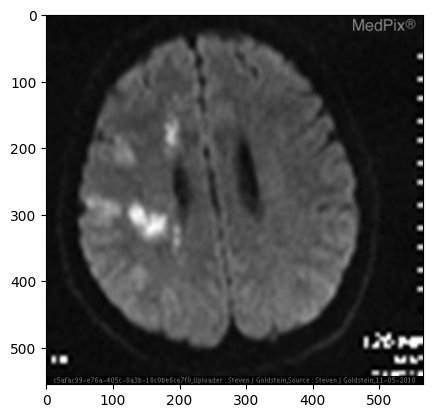

In [8]:
sample = dataset["train"][0]
plt.imshow(sample["image"])
#plt.axis("off")
print(sample["question"])
print(sample["answer"])

In [9]:
for i in range(5):
    print(dataset["train"][i]["image"].size)

(566, 555)
(480, 503)
(1024, 1291)
(766, 978)
(555, 693)


In [10]:
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

In [11]:
train_df.head()

,image,question,answer
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,are regions of the brain infarcted?,yes
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,are the lungs normal appearing?,no
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,which organ system is abnormal in this image?,cardiovascular
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,is the lesion causing significant brainstem he...,no
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,how was this image taken?,mri


In [12]:
train_df.isnull().sum()

,0
image,0
question,0
answer,0


In [13]:
train_df.describe()

,image,question,answer
count,1793,1793,1793
unique,1793,1583,432
top,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,is the heart enlarged?,no
freq,1,12,473


In [14]:
train_df["question_length"] = train_df["question"].apply(
    lambda x: len(x.split())
)
train_df["question_length"].describe()

,question_length
count,1793.000000
mean,6.799219
std,2.428638
min,3.000000
25%,5.000000
50%,6.000000
75%,8.000000
max,21.000000


In [15]:
train_df["answer"].value_counts().head(20)

,count
answer,
no,473
yes,467
axial,31
right,20
pa,14
left,13
ct,10
brain,8
with contrast,7


In [16]:
train_df["answer_length"] = train_df["answer"].apply(
    lambda x: len(str(x).split())
)
train_df["answer_length"].describe()

,answer_length
count,1793.000000
mean,1.626882
std,1.538092
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,17.000000


In [17]:
def question_type(question):
    q = question.lower()
    closed_words = ("is","are","does","do","can","was","were","has","have")
    if q.startswith(closed_words):
        return "closed"
    return "open"

In [18]:
train_df["type"] = train_df["question"].apply(question_type)
test_df["type"] = test_df["question"].apply(question_type)

In [19]:
train_df.head(50)

,image,question,answer,question_length,answer_length,type
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,are regions of the brain infarcted?,yes,6,1,closed
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,are the lungs normal appearing?,no,5,1,closed
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,which organ system is abnormal in this image?,cardiovascular,8,1,open
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,is the lesion causing significant brainstem he...,no,7,1,closed
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,how was this image taken?,mri,5,1,open
5,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,what is the condition of the patient,blind loop syndrome,7,3,open
6,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,what abnormality is seen?,blind-ending loop of bowel arising from the cecum,4,8,open
7,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,what is the location of the mass?,pineal region,7,2,open
8,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,where is the mass?,pineal region,4,2,open
9,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,is this image in the transverse plane?,yes,7,1,closed


In [20]:
train_df["type"].value_counts()

,count
type,
closed,1015
open,778


In [21]:
train_df.drop(columns=["image"]).to_csv(
    "train_metadata.csv",
    index=False
)

test_df.drop(columns=["image"]).to_csv(
    "test_metadata.csv",
    index=False
)

In [22]:
dataset.save_to_disk("vqa_rad_dataset")

Saving the dataset (0/1 shards):   0%|          | 0/1793 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/451 [00:00<?, ? examples/s]

In [23]:
#from datasets import load_from_disk
#dataset = load_from_disk("vqa_rad_dataset")

#Pre Trained VLM

In [24]:
from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,)

In [25]:
model_name = "Qwen/Qwen2.5-VL-3B-Instruct"
processor = AutoProcessor.from_pretrained(model_name)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

In [26]:
sample = train_df.iloc[0]
question = sample["question"]
print(question)

are regions of the brain infarcted?


In [27]:
img_bytes = sample["image"]["bytes"]
image = Image.open(io.BytesIO(img_bytes)).convert("RGB")

In [28]:
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image,
            },
            {
                "type": "text",
                "text": question,
            },
        ],
    }
]

In [29]:
text = processor.apply_chat_template(
    messages, tokenize=False,add_generation_prompt=True)

In [30]:
type(image)

PIL.Image.Image

In [31]:
inputs = processor(text=[text],images=[image],return_tensors="pt")
inputs = inputs.to(model.device)

In [32]:
generated_ids = model.generate(
    **inputs,max_new_tokens=40)

In [33]:
generated_ids = generated_ids[:, inputs.input_ids.shape[1]:]
prediction = processor.batch_decode(generated_ids,skip_special_tokens=True)[0]

print(prediction)

Yes, the image shows regions of the brain that appear to be infarcted. Infarcts are areas of dead tissue in the brain caused by a lack of blood supply, typically due to


In [34]:
sample = train_df.iloc[0]
print(type(sample["image"]))
print(sample["image"])

<class 'dict'>
{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\t\t\x08\n\x0c\x14\r\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c $.\' ",#\x1c\x1c(7),01444\x1f\'9=82<.342\xff\xdb\x00C\x01\t\t\t\x0c\x0b\x0c\x18\r\r\x182!\x1c!22222222222222222222222222222222222222222222222222\xff\xc0\x00\x11\x08\x02+\x026\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\x18\x19\x1a%&\'()*456789:CDEFGHIJSTUVWXYZcdefghijstuvwxyz\x83\x84\x85\x86\x87\x88\x89\x8a\x92\x93\x94\x95\x96\x97\x98\x99\x9a\xa2\xa3\xa4\xa5\xa6\xa7\xa8\xa9\xaa\xb2\xb3\xb4\xb5\xb6\xb7\xb8\xb9\xba\xc2\xc3\xc4\xc5\xc6\xc7\x

In [35]:
image = Image.open(
    io.BytesIO(sample["image"]["bytes"])
).convert("RGB")

In [36]:
type(image)

PIL.Image.Image

In [37]:
def predict(image_dict, question):

    image = Image.open(
        io.BytesIO(image_dict["bytes"])
    ).convert("RGB")

    messages = [
        {
            "role": "user",
            "content": [
                {"type":"image","image":image},
                {"type":"text","text":question},
            ]
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = processor(
        text=[text],
        images=[image],
        return_tensors="pt"
    )

    inputs = inputs.to(model.device)

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=40
    )

    generated_ids = generated_ids[:, inputs.input_ids.shape[1]:]

    answer = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True
    )[0]

    return answer

In [38]:
predict(
    train_df.iloc[5]["image"],
    train_df.iloc[5]["question"])

"The image appears to be a CT scan of the abdomen, which shows various structures including the intestines, liver, and other abdominal organs. However, without specific clinical information or further context, it's"

In [39]:
predictions = []
for idx, row in test_df.iterrows():
    pred = predict(
        row["image"],
        row["question"]
    )
    predictions.append(pred)
    if idx % 20 == 0:
        print(idx)

0
20
40
60
80
100
120
140
160
180
200
220
240
260
280
300
320
340
360
380
400
420
440


In [40]:
test_df["prediction"] = predictions

In [41]:
test_df.head()

,image,question,answer,type,prediction
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,is there evidence of an aortic aneurysm?,yes,closed,"The image provided is a chest X-ray, and it do..."
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,is there airspace consolidation on the left side?,yes,closed,"Yes, there is airspace consolidation on the le..."
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,is there any intraparenchymal abnormalities in...,no,closed,The image provided is a chest X-ray showing a ...
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,which side of the heart border is obscured?,right,open,The right side of the heart border is obscured...
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,where are the kidney?,not seen here,open,"In the image provided, the kidneys are located..."


In [42]:
test_df.to_csv(
    "qwen25vl_predictions.csv",
    index=False)

In [43]:
from google.colab import files
files.download("qwen25vl_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>